In [1]:
# import the liabrary
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings


In [2]:
warnings.filterwarnings('ignore')

In [3]:
# import the dataset
df=pd.read_excel('P659_World_development_dataset.xlsx')
df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


## data cleaning

In [4]:
df.shape

(2704, 25)

In [5]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [6]:
df.describe()

,Birth Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,Health Exp % GDP,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban
count,2585.000000,2.125000e+03,1718.000000,185.000000,1.785000e+03,2395.000000,1416.000000,2444.000000,2531.000000,1880.000000,2568.000000,2568.000000,2537.000000,2704.0,2484.000000,2484.000000,2484.000000,2.704000e+03,2678.000000
mean,0.022715,1.423071e+05,39.999418,94.875676,7.723684e+04,0.064170,302.068503,0.032813,0.239747,0.148103,71.159268,66.461838,0.578124,1.0,0.303051,0.623481,0.073465,3.145729e+07,0.562953
std,0.011338,6.159288e+05,57.318588,54.791906,2.599239e+05,0.026325,273.299686,0.029968,0.260132,0.171829,10.708262,9.390217,0.474647,0.0,0.106577,0.069660,0.049541,1.242894e+08,0.245897
min,0.007000,7.000000e+00,1.000000,1.000000,8.000000e+00,0.008000,12.000000,0.002000,0.000000,0.005000,39.000000,37.000000,0.000000,1.0,0.118000,0.474000,0.003000,1.887600e+04,0.082000
25%,0.013000,1.360000e+03,13.000000,48.000000,3.737000e+03,0.046000,156.000000,0.009000,0.000000,0.080000,64.000000,61.000000,0.100000,1.0,0.204750,0.559000,0.033000,8.783360e+05,0.356000
50%,0.020000,8.529000e+03,26.000000,94.000000,1.433800e+04,0.061000,239.000000,0.020000,0.100000,0.120000,75.000000,69.000000,0.500000,1.0,0.299500,0.642500,0.052000,5.800324e+06,0.560000
75%,0.031000,5.910800e+04,45.000000,142.000000,4.185200e+04,0.079000,344.750000,0.053000,0.400000,0.173000,79.000000,73.250000,0.900000,1.0,0.402000,0.676000,0.112000,2.014089e+07,0.765000
max,0.053000,8.286892e+06,694.000000,189.000000,2.727728e+06,0.225000,2600.000000,0.141000,1.000000,4.965000,87.000000,88.000000,2.900000,1.0,0.500000,0.858000,0.244000,1.350695e+09,1.000000


In [7]:
df.isnull().sum()

Birth Rate                 119
Business Tax Rate         1281
CO2 Emissions              579
Country                      0
Days to Start Business     986
Ease of Business          2519
Energy Usage               919
GDP                        210
Health Exp % GDP           309
Health Exp/Capita          309
Hours to do Tax           1288
Infant Mortality Rate      260
Internet Usage             173
Lending Interest           824
Life Expectancy Female     136
Life Expectancy Male       136
Mobile Phone Usage         167
Number of Records            0
Population 0-14            220
Population 15-64           220
Population 65+             220
Population Total             0
Population Urban            26
Tourism Inbound            368
Tourism Outbound           471
dtype: int64

In [8]:
percent=(df.isnull().sum()/len(df))*100
percent

Birth Rate                 4.400888
Business Tax Rate         47.374260
CO2 Emissions             21.412722
Country                    0.000000
Days to Start Business    36.464497
Ease of Business          93.158284
Energy Usage              33.986686
GDP                        7.766272
Health Exp % GDP          11.427515
Health Exp/Capita         11.427515
Hours to do Tax           47.633136
Infant Mortality Rate      9.615385
Internet Usage             6.397929
Lending Interest          30.473373
Life Expectancy Female     5.029586
Life Expectancy Male       5.029586
Mobile Phone Usage         6.176036
Number of Records          0.000000
Population 0-14            8.136095
Population 15-64           8.136095
Population 65+             8.136095
Population Total           0.000000
Population Urban           0.961538
Tourism Inbound           13.609467
Tourism Outbound          17.418639
dtype: float64

In [9]:
df.drop(columns=percent[percent > 50].index, inplace=True)

In [10]:
df.drop('Number of Records',axis=True,inplace=True)

In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [12]:
text=df.select_dtypes(include='object')
df[text.columns]=text.fillna(text.mode().iloc[0])

In [13]:
df.isnull().sum()

Birth Rate                0
Business Tax Rate         0
CO2 Emissions             0
Country                   0
Days to Start Business    0
Energy Usage              0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Hours to do Tax           0
Infant Mortality Rate     0
Internet Usage            0
Lending Interest          0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64

In [14]:
df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,44.1%,87931.0,Algeria,39.999418,26998.000000,"$54,790,058,957",0.035,$60,302.068503,...,71.0,67.0,0.0,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,44.1%,9542.0,Angola,39.999418,7499.000000,"$9,129,594,819",0.034,$22,302.068503,...,47.0,44.0,0.0,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,44.1%,1617.0,Benin,39.999418,1983.000000,"$2,359,122,303",0.043,$15,302.068503,...,57.0,53.0,0.0,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,44.1%,4276.0,Botswana,39.999418,1836.000000,"$5,788,311,645",0.047,$152,302.068503,...,52.0,49.0,0.1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,44.1%,1041.0,Burkina Faso,39.999418,77236.840896,"$2,610,959,139",0.051,$12,302.068503,...,52.0,49.0,0.0,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


In [15]:
df.drop_duplicates(inplace=True)

In [16]:
for col in df.columns:
    print(col, "=", df[col].unique())
    print('-----------------------------------')

Birth Rate = [0.02       0.05       0.043      0.027      0.046      0.042
 0.041      0.039      0.051      0.048      0.038      0.03
 0.025      0.04       0.044      0.034      0.045      0.035
 0.031      0.022      0.017      0.032      0.053      0.036
 0.019      0.049      0.024      0.033      0.013      0.015
 0.028      0.023      0.014      0.012      0.008      0.026
 0.009      0.018      0.021      0.011      0.01       0.02271489
 0.029      0.016      0.037      0.047      0.007      0.052     ]
-----------------------------------
Business Tax Rate = ['44.1%' '76.9%' '52.1%' '75.7%' '17.1%' '47.5%' '279.7%' '50.6%' '65.7%'
 '74.0%' '217.9%' '286.5%' '64.9%' '47.3%' '37.8%' '54.3%' '84.5%' '30.3%'
 '45.1%' '286.0%' '39.8%' '80.7%' '54.2%' '49.8%' '28.8%' '46.9%' '33.4%'
 '51.4%' '94.7%' '26.2%' '51.7%' '37.5%' '25.8%' '42.3%' '31.6%' '46.8%'
 '50.3%' '48.4%' '272.0%' '37.6%' '49.7%' '36.3%' '43.8%' '52.5%' '60.6%'
 '36.9%' '15.4%' '32.3%' '36.6%' '46.4%' '35.3%' '40.8%

In [17]:
cols=['Business Tax Rate','GDP','Health Exp/Capita','Tourism Inbound','Tourism Outbound']
for col in cols:
    df[col]=(
        df[col]
        .astype(str)
        .str.replace('$','',regex=False)
        .str.replace('%','',regex=False)
        .str.replace(',','',regex=False)
        .str.strip()
    )

In [18]:
for col in cols:
    df[col]=pd.to_numeric(df[col],errors='coerce')

In [19]:
for col in df.columns:
    print(col, "=", df[col].unique())
    print('-----------------------------------')

Birth Rate = [0.02       0.05       0.043      0.027      0.046      0.042
 0.041      0.039      0.051      0.048      0.038      0.03
 0.025      0.04       0.044      0.034      0.045      0.035
 0.031      0.022      0.017      0.032      0.053      0.036
 0.019      0.049      0.024      0.033      0.013      0.015
 0.028      0.023      0.014      0.012      0.008      0.026
 0.009      0.018      0.021      0.011      0.01       0.02271489
 0.029      0.016      0.037      0.047      0.007      0.052     ]
-----------------------------------
Business Tax Rate = [ 44.1  76.9  52.1  75.7  17.1  47.5 279.7  50.6  65.7  74.  217.9 286.5
  64.9  47.3  37.8  54.3  84.5  30.3  45.1 286.   39.8  80.7  54.2  49.8
  28.8  46.9  33.4  51.4  94.7  26.2  51.7  37.5  25.8  42.3  31.6  46.8
  50.3  48.4 272.   37.6  49.7  36.3  43.8  52.5  60.6  36.9  15.4  32.3
  36.6  46.4  35.3  40.8  21.5  80.   57.   24.1  66.6  35.4  68.1  35.2
  36.    9.3  32.5  43.1  47.2  27.7  56.7  79.9  96.7  39.9

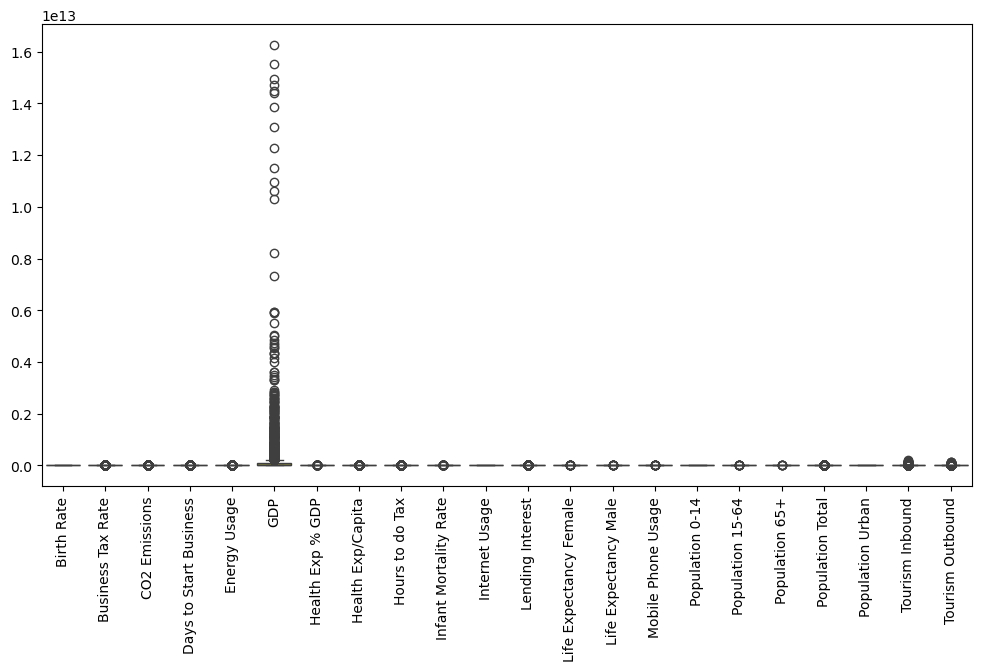

In [20]:
plt.figure(figsize=(12,6))
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

In [21]:
df_numeric = df.select_dtypes(include='number')

Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [22]:
for col in df_numeric.columns:
    lower = lower_bound[col]
    upper = upper_bound[col]
    
    df_numeric[col] = df_numeric[col].clip(lower, upper)

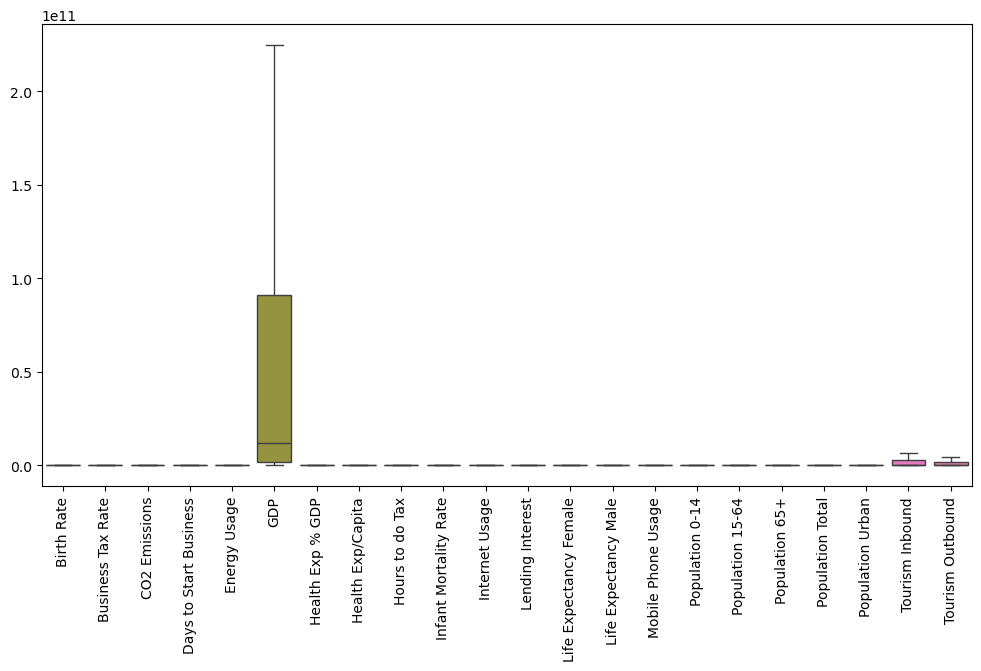

In [23]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_numeric)
plt.xticks(rotation=90)
plt.show()

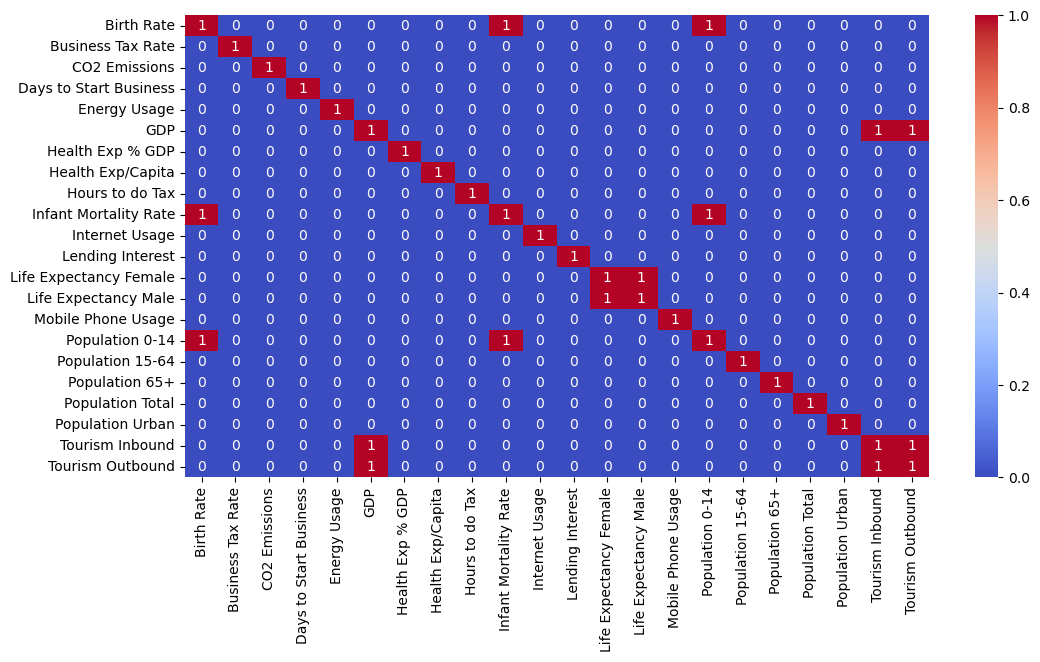

In [24]:
plt.figure(figsize=(12,6))
sns.heatmap(df_numeric.corr()>0.8,annot=True,cmap='coolwarm')
plt.show()

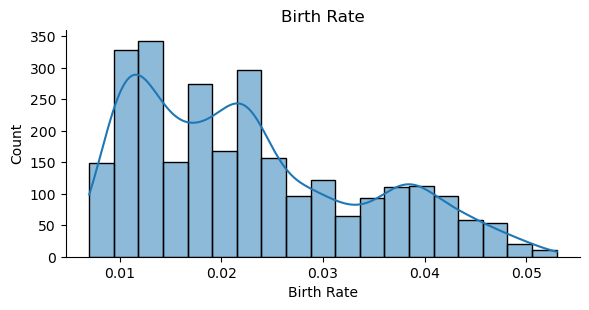

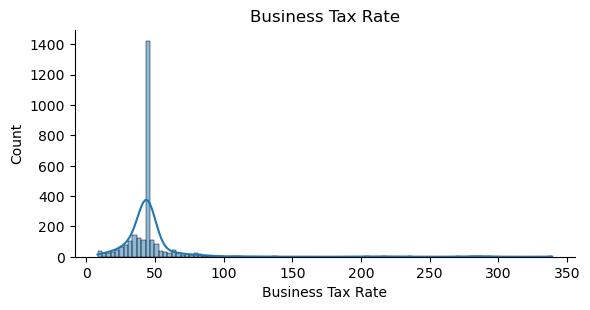

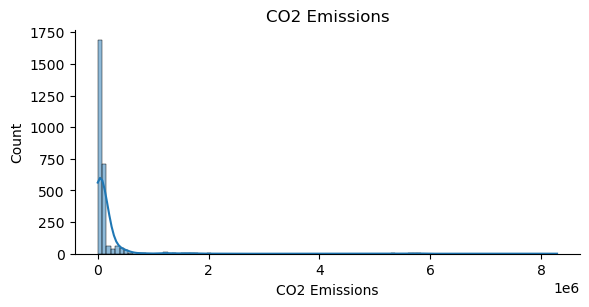

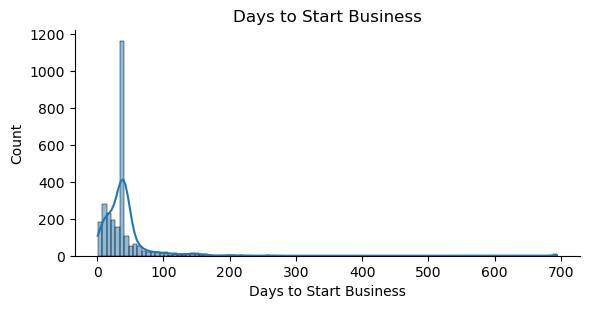

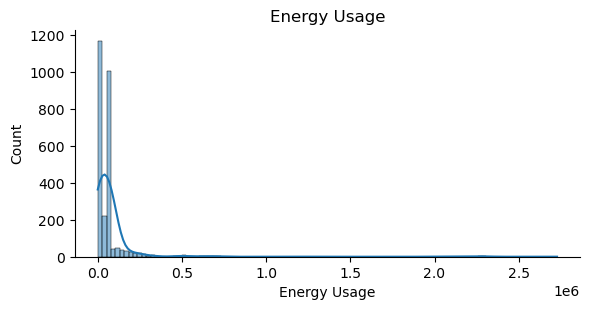

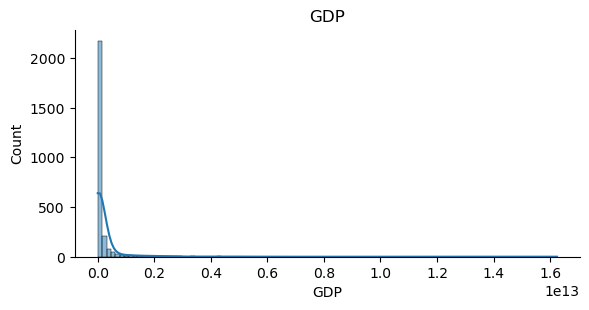

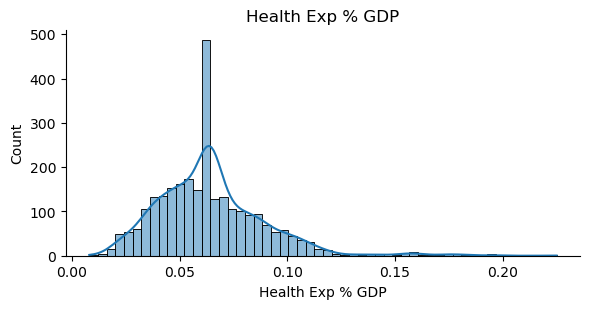

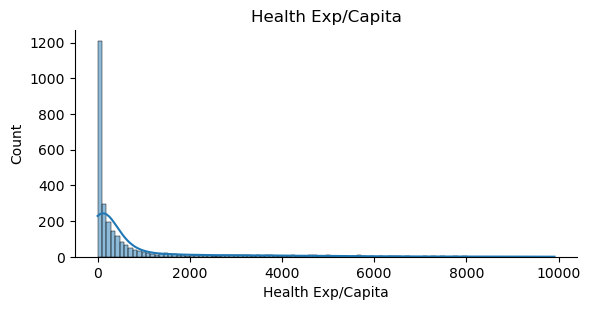

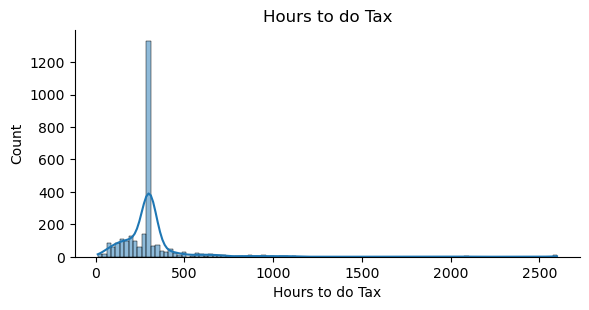

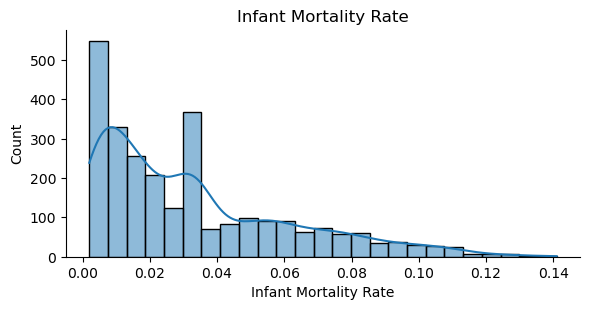

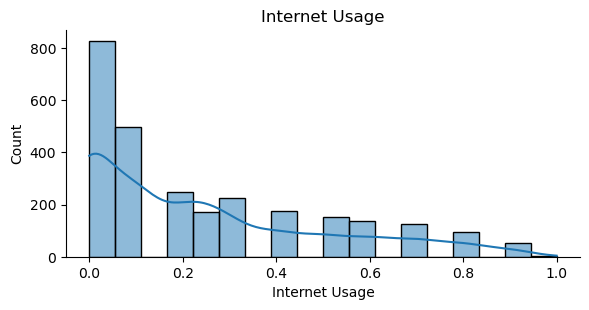

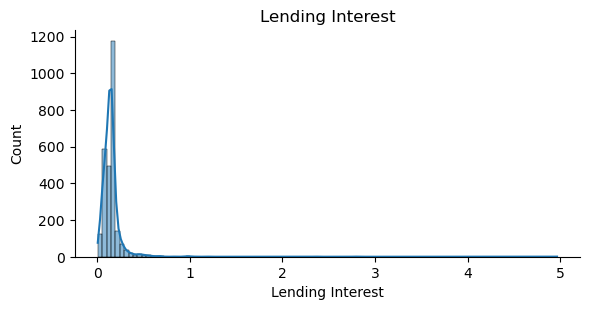

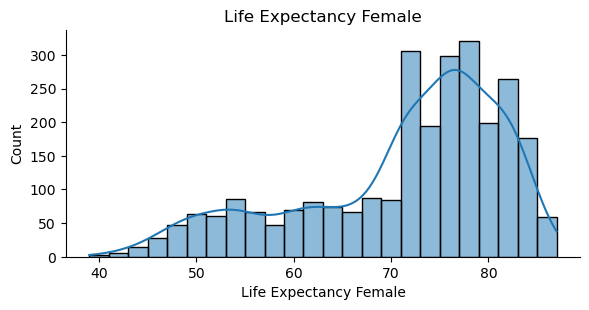

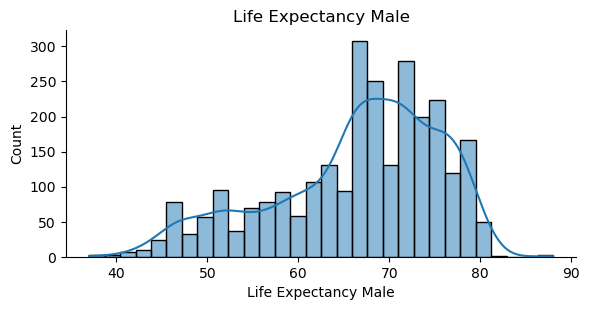

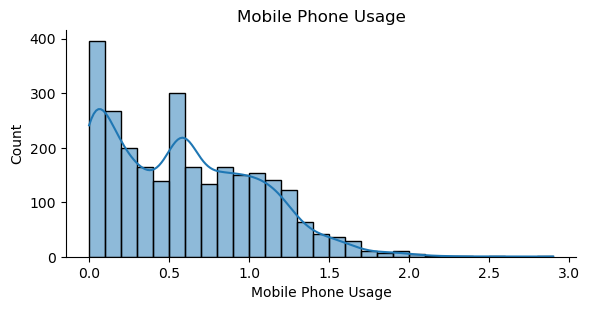

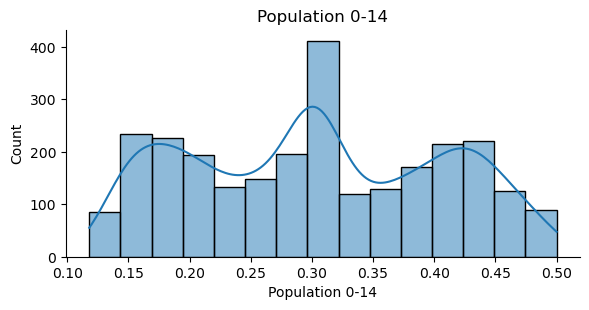

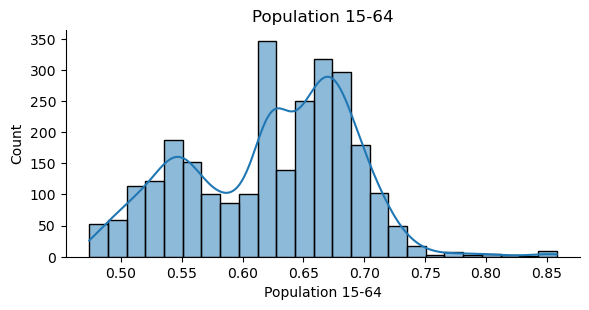

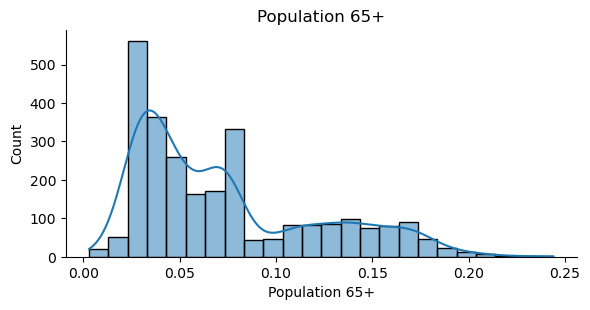

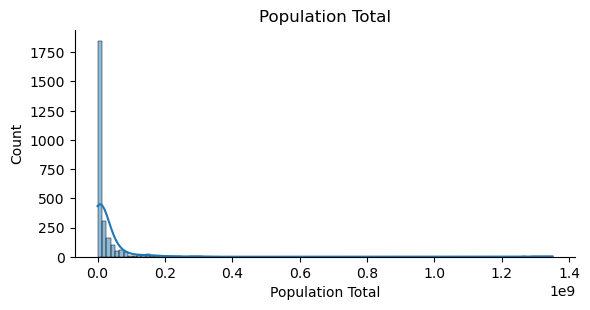

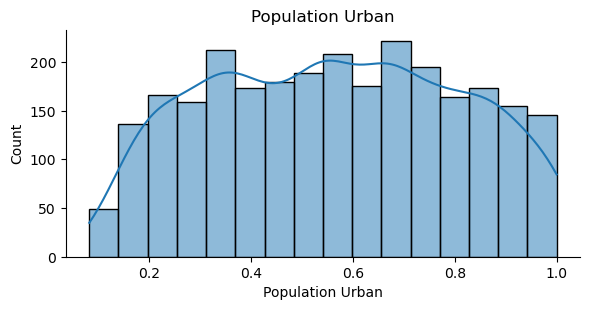

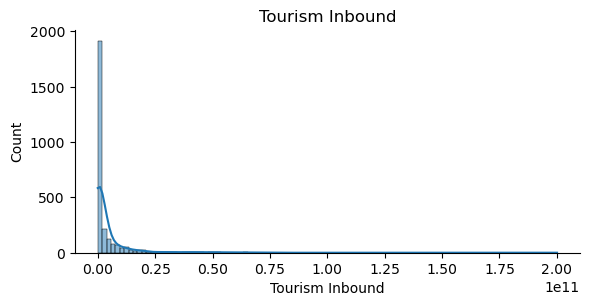

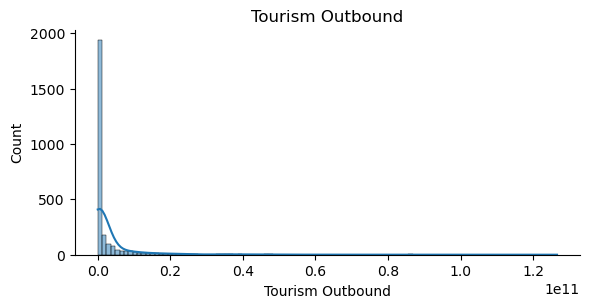

In [25]:
for col in df.select_dtypes(include='number').columns:
    sns.displot(df,x=col,
               kde=True,
               kind='hist',
               height=3,
               aspect=2)
    plt.title(col)
    plt.show()

In [26]:
skewness = df.select_dtypes(include='number').skew()
print(skewness)

Birth Rate                 0.677203
Business Tax Rate          6.154221
CO2 Emissions              9.760611
Days to Start Business     9.327939
Energy Usage               8.689642
GDP                        9.806247
Health Exp % GDP           1.253465
Health Exp/Capita          3.024864
Hours to do Tax            6.203334
Infant Mortality Rate      1.103447
Internet Usage             0.972557
Lending Interest          18.627787
Life Expectancy Female    -0.914833
Life Expectancy Male      -0.723904
Mobile Phone Usage         0.588033
Population 0-14            0.062242
Population 15-64          -0.194971
Population 65+             0.959664
Population Total           8.788164
Population Urban           0.012579
Tourism Inbound            7.608937
Tourism Outbound           5.740932
dtype: float64


In [27]:
right_skewed = skewness[skewness > 0.5].index
left_skewed = skewness[skewness < -0.5].index
normal = skewness[(skewness >= -0.5) & (skewness <= 0.5)].index

In [28]:
print("Right Skewed Columns:", list(right_skewed))
print('-----------------------------------')
print("Left Skewed Columns:", list(left_skewed))
print('-----------------------------------')

print("Normal Columns:", list(normal))

Right Skewed Columns: ['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Days to Start Business', 'Energy Usage', 'GDP', 'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax', 'Infant Mortality Rate', 'Internet Usage', 'Lending Interest', 'Mobile Phone Usage', 'Population 65+', 'Population Total', 'Tourism Inbound', 'Tourism Outbound']
-----------------------------------
Left Skewed Columns: ['Life Expectancy Female', 'Life Expectancy Male']
-----------------------------------
Normal Columns: ['Population 0-14', 'Population 15-64', 'Population Urban']


In [29]:
df[col] = np.log1p(df[col])

In [30]:
df[col] = np.square(df[col])

## feature scaling

In [31]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_data=pd.DataFrame(scaler.fit_transform(df_numeric),columns=df_numeric.columns)

In [32]:
scaled_data.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,...,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,-0.244939,0.256055,0.079013,0.307036,-0.518362,-0.051458,-1.283248,-0.676385,0.311788,0.048763,...,-0.016376,0.057938,-1.265266,0.381370,-0.066436,-0.726908,1.090800,0.147333,-0.692957,-0.596262
1,2.461670,0.256055,-0.693763,0.307036,-0.915875,-0.600943,-1.328445,-0.756772,0.311788,2.677227,...,-2.323409,-2.463272,-1.265266,1.693440,-1.869481,-1.022482,0.021270,-0.976646,-0.721270,-0.625737
2,1.830128,0.256055,-0.771889,0.307036,-1.028326,-0.682420,-0.921670,-0.771580,0.311788,2.051402,...,-1.362145,-1.476712,-1.265266,1.478026,-1.599024,-0.938033,-0.397993,-0.735502,-0.703366,-0.685941
3,0.386604,0.256055,-0.745676,0.307036,-1.031323,-0.641152,-0.740881,-0.481765,0.311788,0.763992,...,-1.842777,-1.915183,-1.046037,0.782825,-0.547248,-0.938033,-0.710175,-0.126509,-0.640911,-0.586228
4,2.100789,0.256055,-0.777568,0.307036,0.505823,-0.679389,-0.560091,-0.777926,0.311788,2.265971,...,-1.842777,-1.915183,-1.265266,1.615108,-1.779329,-0.959145,-0.117991,-1.573377,-0.725850,-0.698483


In [33]:
df.to_csv("Global_development_cleaned.csv", index=False)